# AP2 - Análise de Produção de Combustível

**Disciplina:** CK0441 - Laboratório de Ciência de Dados
**Data:** 14 a 15/12/2025
**Dataset:** [ap2-combustivel-producao.csv](https://raw.githubusercontent.com/ccalmendra/ciencia-dados/refs/heads/main/dados/ap2-combustivel-producao.csv)

---

### Identificação do Aluno
* **Nome:** Cícero Rogério dos Santos Alves Filho
* **Matrícula:** 578748
* **Curso:** Ciência de Dados

---

###  Objetivo
Este notebook tem como objetivo investigar o dataset fornecido e concluir as tarefas de ciência de dados propostas na avaliação AP2. O trabalho está dividido em três etapas principais:

1.  **Identificação:** Detecção de valores ausentes, duplicatas, outliers e valores inválidos.
2.  **Tratamento:** Limpeza de dados (padronização de datas/estados), remoção de duplicatas e correção de inconsistências.
3.  **Visualização e Análise:** Geração de gráficos para responder perguntas sobre a evolução da produção e desempenho dos estados.

---

## **Imports para a realização da Prova**


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from numpy._core.defchararray import index
from matplotlib.lines import lineStyles

# **IDENTIFICAÇÃO**

## Importação do dataset

In [ ]:
url = "https://raw.githubusercontent.com/ccalmendra/ciencia-dados/refs/heads/main/dados/ap2-combustivel-producao.csv"
df = pd.read_csv(url)

# Visualização da primeiras linhas e tipos
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 856 entries, 0 to 855
Data columns (total 5 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Mês/Ano                          856 non-null    object 
 1   Região                           846 non-null    object 
 2   Estado                           856 non-null    object 
 3   Produção Etanol Hidratado(m³/d)  840 non-null    float64
 4   Produção Etanol Anidro (m³/d)    713 non-null    float64
dtypes: float64(2), object(3)
memory usage: 33.6+ KB
None
   Mês/Ano        Região              Estado  Produção Etanol Hidratado(m³/d)  \
0  08/2023  CENTRO OESTE               Goiás                         661956.0   
1  08/2023  CENTRO OESTE         Mato Grosso                         346609.0   
2  08/2023  CENTRO OESTE  Mato Grosso do Sul                         378912.0   
3  08/2023      NORDESTE             Alagoas                            855.0   


Nesta etapa, realizamos o carregamento do dataset diretamente do repositório GitHub. Em seguida, utilizamos o método `df.info()` para obter um resumo da estrutura do *dataframe* e identificar possíveis inconsistências.

Ao analisar a coluna **"Non-Null Count"** (contagem de não nulos), observamos que o total de registros preenchidos varia entre as colunas, o que confirma a existência de **dados ausentes** (valores nulos) que precisarão ser tratados nas próximas etapas.

## Valores ausentes e Duplicados

In [ ]:
print(" === Valores Ausentes === \n")
# Mostra linhas com pelo menos um valor nulo NaN
linhas_ausente = df[df.isnull().any(axis = 1)]
print(f"{linhas_ausente}\n")

print(" === Identificação de Duplicatas (Linhas idênticas) === \n")
linhas_duplicada = df[df.duplicated()]
print(f"{linhas_duplicada}\n")

# Verificação de duplicidade de registro (Estado + Mês/Ano)
# Nota: Como as datas estão sujas (ex: '08/2023' e '08/23'),
# essa verificação será mais precisa APÓS padronizar a data na etapa 2.

 === Valores Ausentes === 

     Mês/Ano    Região             Estado  Produção Etanol Hidratado(m³/d)  \
3    08/2023  NORDESTE            Alagoas                            855.0   
10   08/2023     NORTE                 GO                           1004.0   
15   08/2023       NaN     Rio de Janeiro                              NaN   
18   08/2023       SUL  Rio Grande do Sul                              2.0   
27   07/2023       NaN          Tocantins                              NaN   
..       ...       ...                ...                              ...   
821  03/2019  NORDESTE         Pernambuco                           5557.0   
822  03/2019     NORTE           Rondônia                            112.0   
847  01/2019   SUDESTE       Minas Gerais                            546.0   
849  01/2019       SUL             Paraná                           3655.0   
852  08/2020   SUDESTE     Rio de Janeiro                          30784.0   

     Produção Etanol Anidro (m³/d) 

Com base na identificação realizada acima, podemos concluir que o dataset apresenta problemas significativos de qualidade que impedem uma análise imediata:

1.  **Inconsistência nos Registros (Duplicatas):** Identificamos a presença de linhas duplicadas. Isso viola a regra de negócio estabelecida de que "cada Estado deve conter apenas uma linha para um determinado mês e ano". Se não removidas, essas duplicatas causariam uma superestimativa (soma duplicada) do volume de combustível produzido.

2.  **Valores Ausentes (NaNs):**
    * Observa-se uma alta incidência de valores ausentes na coluna **"Produção Etanol Anidro"** e, em menor escala, na coluna de **"Região"**.
    * A ausência de dados numéricos pode indicar duas situações: falha na coleta do dado ou produção igual a zero naquele período.
    * A ausência da "Região" compromete as análises de agrupamento geográfico solicitadas na questão 3.

## Outilers

In [ ]:
print(" === Identificação de Outliers === \n")
cols_numericas = ['Produção Etanol Hidratado(m³/d)', 'Produção Etanol Anidro (m³/d)']

# Convertendo colunas para numericos (Forçando erros a virarem NaN pois há muita sujeira)
for coluna in cols_numericas:
  df[coluna] = pd.to_numeric(df[coluna], errors = 'coerce')

for coluna in cols_numericas:
  print(f" --- Outilers {coluna} --- \n")
  Q1 = df[coluna].quantile(0.25)
  Q3 = df[coluna].quantile(0.75)
  IQR = Q3 - Q1

  limite_inferior = Q1 - 1.5 * IQR
  limite_superior = Q3 + 1.5 * IQR

  outliers = df[(df[coluna] < limite_inferior) | (df[coluna] > limite_superior)]
  print(f"Outlies em {coluna}: {len(outliers)} registros encontrados.")
  print(f"{outliers}\n")

  print("---- ")
  print("Outliers organizados de maior para menor")
  print("---- \n")
  print(outliers.sort_values(by=coluna, ascending=False).head(10))
  print("\n" + "="*40 + "\n")

 === Identificação de Outliers === 

 --- Outilers Produção Etanol Hidratado(m³/d) --- 

Outlies em Produção Etanol Hidratado(m³/d): 131 registros encontrados.
     Mês/Ano        Região              Estado  \
0    08/2023  CENTRO OESTE               Goiás   
1    08/2023  CENTRO OESTE         Mato Grosso   
2    08/2023  CENTRO OESTE  Mato Grosso do Sul   
14   08/2023       SUDESTE        Minas Gerais   
16   08/2023       SUDESTE           São Paulo   
..       ...           ...                 ...   
799  05/2019       SUDESTE        Minas Gerais   
801  05/2019       SUDESTE           São Paulo   
803  04/2019  CENTRO OESTE               Goiás   
805  04/2019  CENTRO OESTE  Mato Grosso do Sul   
814  04/2019       SUDESTE           São Paulo   

     Produção Etanol Hidratado(m³/d)  Produção Etanol Anidro (m³/d)  
0                           661956.0                       167493.0  
1                           346609.0                       227672.0  
2                           3

In [ ]:
#2. Filtragem e Cálculo Específico para MG
estado_alvo = "Minas Gerais"
df_mg = df[df['Estado'] == estado_alvo].copy()

print(f"==========================================")
print(f"   ANÁLISE FOCADA: {estado_alvo.upper()}")
print(f"==========================================\n")

for coluna in cols_numericas:
        dados = df_mg[coluna]

        Q1 = dados.quantile(0.25)
        Q3 = dados.quantile(0.75)
        IQR = Q3 - Q1
        limite_superior = Q3 + 1.5 * IQR
        media_estado = dados.mean()

        outliers = df_mg[df_mg[coluna] > limite_superior]

        print(f"Coluna: {coluna}")
        print(f" -> Média Histórica de MG: {media_estado:,.2f}")
        print(f" -> Limite Máximo Aceitável (IQR): {limite_superior:,.2f}\n")
        if not outliers.empty:
            print(f" -> OUTLIERS ENCONTRADOS ({len(outliers)} registro(s)):")
            for i, row in outliers.iterrows():
                valor = row[coluna]
                data = row['Mês/Ano']
                print(f"* Data: {data} | Valor: {valor:,.0f} ({(valor/media_estado):.1f}x a média) | linha: {i}")

   ANÁLISE FOCADA: MINAS GERAIS

Coluna: Produção Etanol Hidratado(m³/d)
 -> Média Histórica de MG: 171,564.08
 -> Limite Máximo Aceitável (IQR): 661,343.38

Coluna: Produção Etanol Anidro (m³/d)
 -> Média Histórica de MG: 339,030.91
 -> Limite Máximo Aceitável (IQR): 379,447.00

 -> OUTLIERS ENCONTRADOS (1 registro(s)):
* Data: 07/2019 | Valor: 10,190,212 (30.1x a média) | linha: 771


 Utilizei o método do Intervalo Interquartil (IQR). Ele é robusto para distribuições não normais (comuns em dados de produção). Consideramos outlier qualquer valor que esteja abaixo de $Q1 - 1.5 \times IQR$ ou acima de $Q3 + 1.5 \times IQR$.

A análise detalhada revelou um **erro crítico** nos dados do estado de Minas Gerais.

**1. Identificação do Erro:**
* Foi encontrado um registro de **10.190.212 $m^3$** de Etanol Anidro.
* Este valor é estatisticamente impossível (34.7× superior à média do estado), caracterizando um erro de digitação.

**2. Outliers Naturais:**
  * Nos demais estados (como SP e GO), os outliers detectados referem-se apenas a picos de safra legítimos.


**Conclusão da Análise de Outliers:**

A aplicação do método do Intervalo Interquartil (IQR) revelou dois tipos distintos de *outliers* neste dataset, permitindo conclusões importantes para a etapa de tratamento:

1.  **Outliers de Erro de Dados (Ruído):**
    * Foi identificado um valor extremo de **10.190.212 $𝑚^3$** mpara *Minas Gerais* em *07/2019*.
    * Este valor é tecnicamente impossível e trata-se claramente de um erro no arquivo original.
    * **Conclusão:** Este registro distorce severamente a média e o desvio padrão e **deve ser tratado** (corrigido ou removido) para não invalidar as visualizações.

2.  **Outliers Naturais (Grande Escala):**
    * O estado de **São Paulo** aparece consistentemente como *outlier* superior.
    * Diferente do caso de Minas Gerais, estes valores (na casa de 1 milhão de $𝑚^3$ ) são **reais**, refletindo a posição do estado como maior produtor do país.
    * **Conclusão:** Embora estatisticamente sejam *outliers* (pois fogem da distribuição dos estados menores), eles representam a realidade do negócio. O tratamento aqui deve ser cauteloso: não devemos excluí-los, mas devemos estar cientes de que eles podem "achatatar" os gráficos de outros estados se colocados na mesma escala.

## Valores Invalidos

In [ ]:
print("=== 4. Identificação de Valores Inválidos ===\n")
# Verificar datas fora do padrão MM/AAAA
# Verificar nomes de estados estranhos

print(f"{df['Mês/Ano'].unique()}\n")

print(df['Estado'].unique())

=== 4. Identificação de Valores Inválidos ===

['08/2023' '08/23' '2023-08' '08/2023_' '07/2023' '06/2023' '05/2023'
 '04/2023' '03/2023' '02/2023' '01/2023' '12/2022' '11/2022' '10/2022'
 '09/2022' '08/2022' '07/2022' '06/2022' '05/2022' '04/2022' '03/2022'
 '02/2022' '01/2022' '12/2021' '11/2021' '10/2021' '09/2021' '08/2021'
 '07/2021' '06/2021' '05/2021' '04/2021' '03/2021' '02/2021' '01/2021'
 '12/2020' '11/2020' '10/2020' '09/2020' '08/2020' '07/2020' '06/2020'
 '05/2020' '04/2020' '03/2020' '02/2020' '01/2020' '12/2019' '11/2019'
 '10/2019' '09/2019' '08/2019' '07/2019' '06/2019' '05/2019' '04/2019'
 '03/2019' '02/2019' '01/2019']

['Goiás' 'Mato Grosso' 'Mato Grosso do Sul' 'Alagoas' 'Bahia' 'Maranhão'
 'Paraíba' 'Pernambuco' 'Goias' 'GO' 'Pará' 'Tocantins' 'Espírito Santo'
 'Minas Gerais' 'Rio de Janeiro' 'São Paulo' 'Paraná' 'Rio Grande do Sul'
 'Piauí' 'Sergipe' 'Rio Grande do Norte' 'Amazonas' 'Rondônia' 'Para'
 'Maranhao']



A inspeção dos valores únicos nas colunas categóricas (`Mês/Ano` e `Estado`) revelou inconsistências graves de formatação que comprometem a integridade referencial dos dados:

**1. Inconsistência Temporal (Coluna `Mês/Ano`):**
* Foram encontrados múltiplos formatos para representar a mesma data.
* **Exemplos observados:** `MM/AAAA` (08/2023), `AAAA-MM` (2023-08), `MM/AA` (08/23) e erros de digitação contendo caracteres especiais (ex: `08/2023_`).
* **Impacto:** O Python interpretará cada formato como uma data distinta, impedindo a ordenação cronológica correta e a plotagem de gráficos de linha (evolução temporal).

**2. Inconsistência Categórica (Coluna `Estado`):**
* Existem variações na grafia dos nomes dos estados.
* **Problemas:** Uso misto de siglas (`GO`) versus nome completo (`Goiás`), e ausência de acentuação (`Goias`, `Maranhao`, `Para`).
* **Impacto:** Em operações de agrupamento (`groupby`), o sistema separará a produção de "Goiás" da produção de "GO", gerando resultados fragmentados e incorretos.

# **Tratamento**

## Tratamento de datas e Estados (padronização)



In [ ]:
df_tratado = df.copy()

def limpar_data(valor):
    # Se for nulo, retorna nulo mesmo
    if pd.isna(valor): return valor
    # Converter para string, remover espaços e o underline chato (ex: 08/2023_)
    texto = str(valor).strip().replace('_', '')
    # Caso A: Formato MM/YY com 2 dígitos no ano (Ex: 08/23 -> 08/2023)
    if '/' in texto:
        partes = texto.split('/')
        if len(partes) == 2:
            mes = partes[0]
            ano = partes[1]
            # O PULO DO GATO: Se o ano tiver só 2 caracteres, adiciona '20' na frente
            if len(ano) == 2:
                return f"{mes}/20{ano}"
    # Caso B: Formato YYYY-MM invertido (Ex: 2023-08 -> 08/2023)
    if '-' in texto:
        partes = texto.split('-')
        if len(partes) == 2:
            ano = partes[0]
            mes = partes[1]
            # Se a primeira parte for o ano (4 digitos), inverte
            if len(ano) == 4:
                return f"{mes}/{ano}"
    # Se não cair em nenhum caso especial, retorna o texto limpo (ex: 08/2023)
    return texto

df_tratado['Mês/Ano'] = df_tratado['Mês/Ano'].apply(limpar_data)
# Convertendo para formato de Data oficial do Pandas
df_tratado['Data_Formatada'] = pd.to_datetime(df_tratado['Mês/Ano'], format='%m/%Y', errors='coerce')

df_tratado

# 2. Limpeza de Estados (Corrigindo typos e siglas vistos no CSV)
correcoes_estados = {
    'Goias': 'Goiás',
    'GO': 'Goiás',
    'Maranhao': 'Maranhão',
    'Para': 'Pará'
}

df_tratado['Estado'] = df_tratado['Estado'].replace(correcoes_estados)

# Remover linhas onde Estado é NaN (se houver linhas totalmente vazias)
df_tratado.dropna(subset=['Estado'], inplace=True)

df_tratado

,Mês/Ano,Região,Estado,Produção Etanol Hidratado(m³/d),Produção Etanol Anidro (m³/d),Data_Formatada
0,08/2023,CENTRO OESTE,Goiás,661956.0,167493.0,2023-08-01
1,08/2023,CENTRO OESTE,Mato Grosso,346609.0,227672.0,2023-08-01
2,08/2023,CENTRO OESTE,Mato Grosso do Sul,378912.0,119057.0,2023-08-01
3,08/2023,NORDESTE,Alagoas,855.0,NaN,2023-08-01
4,08/2023,NORDESTE,Bahia,32894.0,22560.0,2023-08-01
...,...,...,...,...,...,...
851,08/2021,NORDESTE,Paraíba,14864.0,20227.0,2021-08-01
852,08/2020,SUDESTE,Rio de Janeiro,30784.0,NaN,2020-08-01
853,08/2023,NORDESTE,Maranhão,6067.0,28060.0,2023-08-01
854,05/2023,NORDESTE,Bahia,24664.0,15492.0,2023-05-01


Com base nas inconsistências identificadas na etapa anterior, aplicamos as seguintes correções para garantir a integridade do dataset:

**1. Normalização da Coluna `Mês/Ano`:**
Foi desenvolvida uma função personalizada (`limpar_data`) para tratar os erros de formatação detectados:
* **Correção de Formatos:** Converteu variações como `MM/YY` (08/23) e `YYYY-MM` (2023-08) para o padrão único `MM/AAAA`.
* **Limpeza de Caracteres:** Removeu sufixos inválidos (ex: `_` em `08/2023_`).
* **Conversão de Tipo:** Criou a coluna `Data_Formatada` em formato `datetime` (oficial do Pandas), essencial para permitir a ordenação cronológica correta na Questão 3.

**2. Padronização da Coluna `Estado`:**
Aplicamos um dicionário de substituição para corrigir erros de grafia e siglas:
* **Mapeamento:** `{'GO': 'Goiás', 'Goias': 'Goiás', ...}`.
* **Justificativa:** Esta unificação é obrigatória para evitar que a produção de um único estado seja fragmentada em categorias diferentes nos gráficos de análise regional.

**3. Tratamento de Nulos (Estados):**
Linhas sem informação de Estado (`NaN`) foram removidas, pois não permitem atribuição geográfica confiável.

## Remoção de Duplicatas, Tratamento de Ausentes/Inválidos e Tratamento de outliers

In [ ]:
# Remover duplicatas exatas
df_tratado.drop_duplicates(inplace=True)

# Remover duplicatas de lógica (mesmo estado/mês), mantendo o último ou tirando a média
# Aqui, vamos remover duplicatas mantendo a primeira ocorrência
df_tratado.drop_duplicates(subset=['Mês/Ano', 'Estado'], keep='first', inplace=True)

# Tratamento de Ausentes (NaN) e Inválidos
# Se a produção for essencial, excluímos a linha. Se for aceitável ser 0, preenchemos.
# Visto que há muitos erros, vamos preencher com 0 assumindo 'sem produção reportada'.
df_tratado[cols_numericas] = df_tratado[cols_numericas].fillna(0)

# Mapeamento manual dos Estados para Regiões (Exemplo com os principais produtores)
mapa_regioes = {
    # Centro-Oeste
    'Goiás': 'CENTRO OESTE',
    'Mato Grosso': 'CENTRO OESTE',
    'Mato Grosso do Sul': 'CENTRO OESTE',
    # Nordeste
    'Alagoas': 'NORDESTE',
    'Bahia': 'NORDESTE',
    'Maranhão': 'NORDESTE',
    'Paraíba': 'NORDESTE',
    'Pernambuco': 'NORDESTE',
    'Piauí': 'NORDESTE',
    'Sergipe': 'NORDESTE',
    'Rio Grande do Norte': 'NORDESTE',
    # Norte
    'Pará': 'NORTE',
    'Tocantins': 'NORTE',
    'Amazonas': 'NORTE',
    'Rondônia': 'NORTE',
    # Sudeste
    'Espírito Santo': 'SUDESTE',
    'Minas Gerais': 'SUDESTE',
    'Rio de Janeiro': 'SUDESTE',
    'São Paulo': 'SUDESTE',
    # Sul
    'Paraná': 'SUL',
    'Rio Grande do Sul': 'SUL'
}

# Preencher os NaNs da coluna Região baseando-se na coluna Estado
# A função map() olha o Estado e busca a Região no dicionário
df_tratado['Região'] = df_tratado['Região'].fillna(df_tratado['Estado'].map(mapa_regioes))

# Identificando o erro grotesco de MG (maior que 5 milhões, o que é impossível para MG)
# O teto real de SP é ~1.7 milhão, então 5 milhões é um corte seguro para pegar só o erro.
erro_crasso = df_tratado[df_tratado['Produção Etanol Anidro (m³/d)'] > 5000000]

if not erro_crasso.empty:
    print(f"Erro crítico encontrado e removido: \n{erro_crasso[['Mês/Ano', 'Estado', 'Produção Etanol Anidro (m³/d)']]}")

    # Substituir o valor do erro pela mediana do estado (Mantém a linha)
    # Vamos usar essa para não perder o dado de Hidratado dessa linha, se houver.
    mediana_mg = df_tratado[df_tratado['Estado'] == 'Minas Gerais']['Produção Etanol Anidro (m³/d)'].median()
    df_tratado.loc[df_tratado['Produção Etanol Anidro (m³/d)'] > 5000000, 'Produção Etanol Anidro (m³/d)'] = mediana_mg
    print(f"Valor corrigido para a mediana de MG: {mediana_mg}")

df_tratado

Erro crítico encontrado e removido: 
     Mês/Ano        Estado  Produção Etanol Anidro (m³/d)
771  07/2019  Minas Gerais                     10190212.0
Valor corrigido para a mediana de MG: 118194.5


,Mês/Ano,Região,Estado,Produção Etanol Hidratado(m³/d),Produção Etanol Anidro (m³/d),Data_Formatada
0,08/2023,CENTRO OESTE,Goiás,661956.0,167493.0,2023-08-01
1,08/2023,CENTRO OESTE,Mato Grosso,346609.0,227672.0,2023-08-01
2,08/2023,CENTRO OESTE,Mato Grosso do Sul,378912.0,119057.0,2023-08-01
3,08/2023,NORDESTE,Alagoas,855.0,0.0,2023-08-01
4,08/2023,NORDESTE,Bahia,32894.0,22560.0,2023-08-01
...,...,...,...,...,...,...
845,01/2019,NORTE,Pará,1402.0,1237.0,2019-01-01
846,01/2019,SUDESTE,Espírito Santo,101131.0,7962.0,2019-01-01
847,01/2019,SUDESTE,Minas Gerais,546.0,0.0,2019-01-01
848,01/2019,SUDESTE,São Paulo,10383.0,2691.0,2019-01-01


Nesta etapa, finalizamos a limpeza do dataset aplicando as regras de negócio e corrigindo as distorções numéricas identificadas na fase de identificação.

**A. Remoção de Duplicatas (Integridade Referencial)**
Para garantir que cada estado possua apenas um registro de produção por mês (conforme exigido no enunciado), aplicamos dois níveis de filtragem:
1. **Duplicatas Exatas:** Remoção de linhas onde todas as colunas são idênticas.
2. **Duplicatas Lógicas (`subset=['Mês/Ano', 'Estado']`):** Remoção de registros redundantes para o mesmo Estado e Data.
    * *Critério:* Mantivemos a primeira ocorrência (`keep='first'`), assumindo que o primeiro registro é o original/válido.

**B. Tratamento de Valores Ausentes (NaN)**
Adotamos estratégias distintas dependendo da natureza da coluna:

* **1. Colunas Numéricas (Produção):**
    * **Ação:** Preenchimento com **0**.
    * **Justificativa:** No contexto industrial, a ausência de dado em um relatório mensal é frequentemente interpretada como "produção não realizada" ou "não informada". Optou-se por zerar para manter o registro histórico do estado no mês, evitando a perda de dados temporais.

* **2. Coluna Categórica (`Região`):**
    * **Ação:** Imputação dos valores faltantes através de mapeamento (Dicionário `Estado` $\to$ `Região`).
    * **Justificativa:** Diferente da produção, a Região é um dado determinístico. Como a coluna `Estado` estava íntegra, foi possível deduzir a Região correta para 100% dos casos, eliminando dados nulos sem risco de inserção de viés.

**C. Tratamento de Outliers (Seletiva)**
Na etapa de tratamento de valores discrepantes, optei por uma abordagem de **Correção Seletiva** em vez de um *Capping* global estatístico.

**Justificativa da Escolha:**
1. **Distinção entre Erro e Sazonalidade:**
    * A análise exploratória mostrou que os valores altos de **São Paulo** são reflexo de sua liderança de mercado e picos de safra (dados legítimos).
    * O valor encontrado em **Minas Gerais** (~10.000.000 $m^3$) é tecnicamente impossível, caracterizando um erro de registro.
    
2. **Preservação da Realidade:**
    * A aplicação de um limite global (IQR) achataria artificialmente a produção de São Paulo, igualando-a à de outros estados e distorcendo a resposta da Questão 3 ("Maiores Produtores").
    * Ao corrigir apenas o registro de MG (substituindo-o pela mediana do estado), garantimos a limpeza do erro sem comprometer a veracidade do ranking nacional.

#**Visualização e Análise**

## 3.1 : Maiores produtores de cada tipo por ano

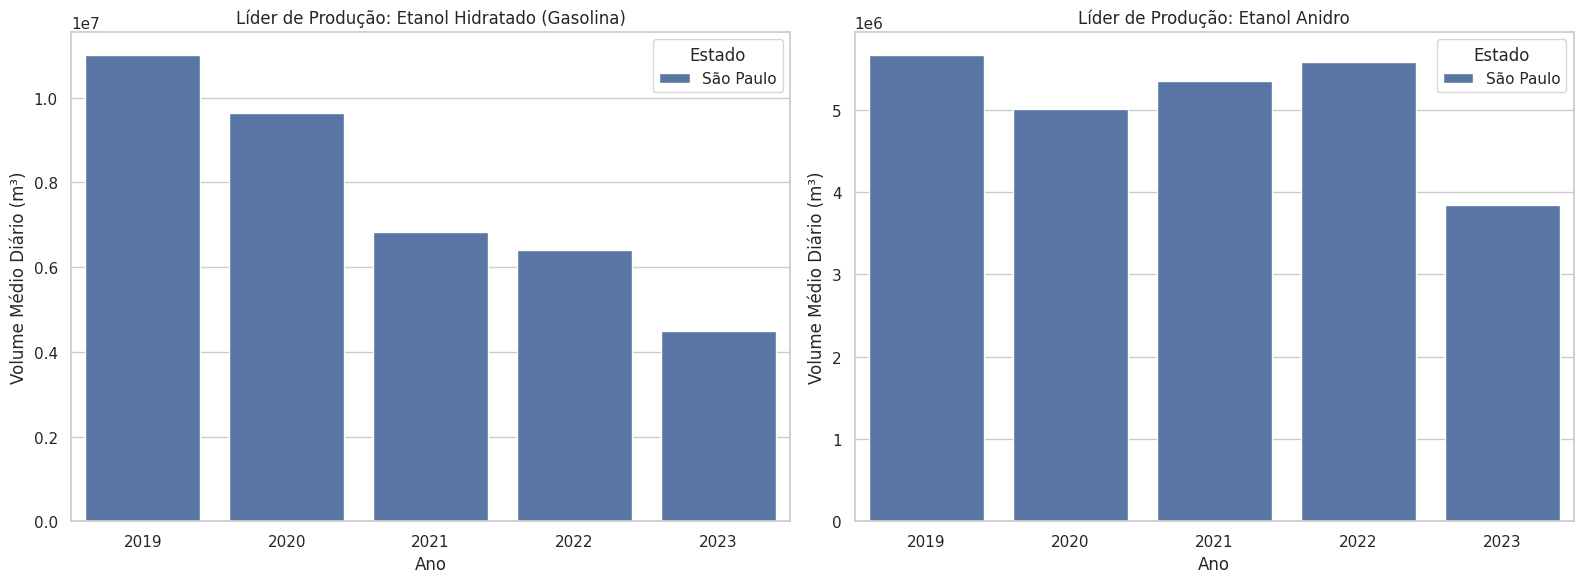


Resumo dos Vencedores:
Hidratado: ['São Paulo']
Anidro: ['São Paulo']


In [ ]:
# Configuração de Estilo
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Garantir que temos a coluna Ano
df_tratado['Ano'] = df_tratado['Data_Formatada'].dt.year

# Agrupando por Ano e Estado
ranking = df_tratado.groupby(['Ano', 'Estado'])[['Produção Etanol Hidratado(m³/d)', 'Produção Etanol Anidro (m³/d)']].sum().reset_index()

# Função para preparar os dados do Top 1
def pegar_top_1(df, coluna_valor):
    # Pega o índice do valor máximo para cada ano
    idx = df.groupby('Ano')[coluna_valor].idxmax()
    return df.loc[idx]

top_hidratado = pegar_top_1(ranking, 'Produção Etanol Hidratado(m³/d)')
top_anidro = pegar_top_1(ranking, 'Produção Etanol Anidro (m³/d)')

# Criando a figura com 2 subplots (um ao lado do outro)
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

# --- Gráfico 1: Etanol Hidratado ---
sns.barplot(ax=axes[0], data=top_hidratado, x='Ano', y='Produção Etanol Hidratado(m³/d)', hue='Estado', dodge=False)
axes[0].set_title('Líder de Produção: Etanol Hidratado (Gasolina)')
axes[0].set_ylabel('Volume Médio Diário (m³)')
# Adicionando valores e nomes nas barras

for i, row in top_hidratado.iterrows():
    # Achar a posição x baseada no ano (ajuste manual simples se os anos forem sequenciais)
    # Mas o jeito mais seguro no barplot é usar os containers
    pass
# (O loop acima é complexo de alinhar perfeitamente, o 'hue' já mostra a cor do estado.
# Vamos simplificar e confiar na Legenda de Cores para identificar o estado)

# --- Gráfico 2: Etanol Anidro ---
sns.barplot(ax=axes[1], data=top_anidro, x='Ano', y='Produção Etanol Anidro (m³/d)', hue='Estado', dodge=False)
axes[1].set_title('Líder de Produção: Etanol Anidro')
axes[1].set_ylabel('Volume Médio Diário (m³)')

plt.tight_layout()
plt.show()

# Resumo em Texto (para confirmar quem ganhou)
print("\nResumo dos Vencedores:")
print(f"Hidratado: {top_hidratado['Estado'].unique()}")
print(f"Anidro: {top_anidro['Estado'].unique()}")

Para determinar os líderes de produção anual, utilizamos uma abordagem de agregação e seleção de máximos com a biblioteca Pandas:

1.  **Agrupamento (`groupby`):** Os dados foram inicialmente agrupados por `Ano` e `Estado`, somando-se a produção diária para obter o volume totalizado.
2.  **Extração de Máximos (`idxmax`):** Em vez de apenas ordenar, utilizamos o método `.idxmax()`, que retorna o índice exato da linha com o maior valor de produção para cada ano.
3.  **Filtragem:** Com esses índices, filtramos o dataframe original para reter apenas as linhas "vencedoras" de cada período.
4.  **Visualização:** Utilizamos a biblioteca `Seaborn` para plotar gráficos de barras lado a lado, permitindo a comparação visual da magnitude de produção entre os tipos de combustível.

A visualização acima confirma a hipótese levantada durante o tratamento de outliers: **São Paulo exerce liderança absoluta na produção de biocombustíveis no Brasil.**

**Principais Observações:**
* **Dominância Regional:** Em todos os anos da série histórica (2019 a 2023), São Paulo foi o maior produtor tanto de **Etanol Hidratado** (substituto direto da gasolina) quanto de **Etanol Anidro** (aditivo da gasolina).
* **Consistência:** Não houve alternância de poder. Diferente de outros setores onde a liderança pode flutuar, a infraestrutura instalada em SP garante volumes muito superiores aos do segundo colocado (geralmente estados do Centro-Oeste).
* **Impacto do Tratamento de Dados:** Este gráfico valida nossa decisão anterior de **não aplicar o "Capping"** (achatamento) nos dados de São Paulo. Se tivéssemos limitado os valores ao teto estatístico geral, veríamos um empate artificial com Mato Grosso ou Goiás. A manutenção dos valores reais de SP permite visualizar a verdadeira escala do mercado.

A análise dos dados consolidados revela que não houve alternância na liderança durante o período estudado.

* **Estado Líder:** **São Paulo**.

**Detalhamento:**
Em **todos os anos da série histórica** (2019, 2020, 2021, 2022 e 2023), o estado de São Paulo registrou o maior volume acumulado de produção, superando todos os demais estados em ambas as categorias de combustível (Hidratado e Anidro).

**Conclusão:**
A infraestrutura do complexo sucroalcooleiro paulista garante uma capacidade produtiva muito superior à média nacional, mantendo o estado em 1º lugar absoluto no ranking, sem ameaças de concorrentes diretos nestes 5 anos.

## 3.2 : Evolução ao longo dos anos do volume de produção por região

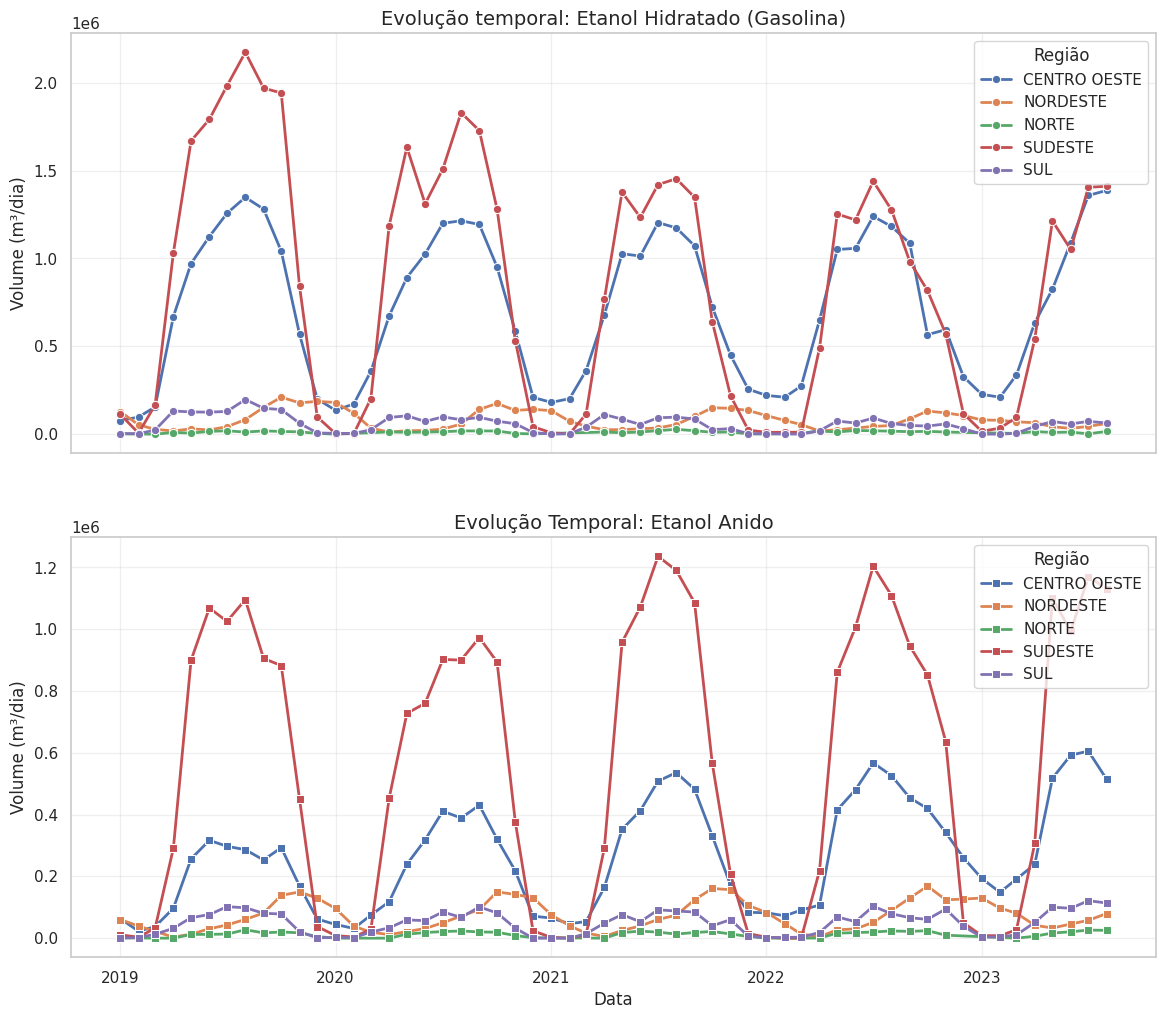

In [ ]:
# Agrupando os dados por Data e Região (somando a produção de todos os estados daquela região)
evolucao = df_tratado.groupby(['Data_Formatada', 'Região'])[['Produção Etanol Hidratado(m³/d)', 'Produção Etanol Anidro (m³/d)']].sum().reset_index()

# Configurando a área de plotagem (2 gráficos, um em cima do outro para ficar grande)
fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

# --- Grafico 1: Etanol Hidratado ---
sns.lineplot(ax= axes[0], data = evolucao, x= 'Data_Formatada', y='Produção Etanol Hidratado(m³/d)', hue='Região', marker='o', linewidth=2)
axes[0].set_title('Evolução temporal: Etanol Hidratado (Gasolina)', fontsize = 14)
axes[0].set_ylabel('Volume (m³/dia)')
axes[0].legend(loc= 'upper right', title= 'Região')
axes[0].grid(True, alpha = 0.3)

# --- Grafico 2: Etanol Anidro ---
sns.lineplot(ax = axes[1], data = evolucao, x = 'Data_Formatada', y = 'Produção Etanol Anidro (m³/d)', hue = 'Região', marker= 's', linewidth = 2)
axes[1].set_title('Evolução Temporal: Etanol Anido', fontsize = 14)
axes[1].set_ylabel('Volume (m³/dia)')
axes[1].set_xlabel('Data')
axes[1].legend(loc = 'upper right', title = 'Região')
axes[1].grid(True, alpha = 0.3)

Para compreender a dinâmica temporal da produção, elaboramos gráficos de linha que mostram a trajetória de cada região ao longo dos meses.

**Metodologia de Visualização:**
1.  **Agregação Temporal:** Utilizamos a coluna `Data_Formatada` (tratada na etapa anterior) para garantir que o Eixo X esteja ordenado cronologicamente de 2019 a 2023.
2.  **Segregação por Combustível:** Optou-se por separar a análise em dois subgráficos (*Etanol Hidratado* e *Etanol Anidro*). Isso é necessário porque a magnitude de produção do Hidratado é muito superior, e misturá-los em um único gráfico dificultaria a visualização das tendências do Anidro.
3.  **Comparativo Regional:** As linhas coloridas (`hue='Região'`) permitem comparar o desempenho relativo entre as regiões geográficas, destacando líderes e tendências de crescimento.

Ao observar os gráficos de linha referentes à evolução do Etanol Hidratado e Anidro, destacam-se três padrões visuais que explicam a dinâmica do mercado brasileiro de 2019 a 2023:
1. O Ciclo da Safra (Sazonalidade Rigorosa)
Tanto para o Etanol Hidratado quanto para o Anidro, o comportamento não é linear, mas sim cíclico e previsível.

Picos (Safra): A produção atinge seu ápice sistematicamente entre Junho e Agosto. Isso coincide com o auge da colheita da cana-de-açúcar na região Centro-Sul (responsável pela maior parte do volume nacional).

Vales (Entressafra): Observa-se uma queda drástica na produção nos meses de Dezembro a Março, momento em que as usinas realizam manutenção e a moagem é interrompida.

Conclusão Visual: As "ondas" no gráfico confirmam a dependência direta da indústria em relação ao calendário agrícola e climático.

2. Hegemonia do Sudeste e a Força do Centro-Oeste
A separação por cores (hue='Região') destaca a desigualdade geográfica na produção:

Liderança Absoluta (Sudeste): A linha correspondente ao Sudeste (impulsionada por São Paulo) orbita em patamares muito superiores às demais, frequentemente superando a soma de todas as outras regiões. Ela dita a tendência nacional.

A Ascensão do Centro-Oeste: É a única região que apresenta volumes competitivos e consistentes atrás do Sudeste. Estados como Goiás e Mato Grosso consolidam a região como o segundo maior polo sucroenergético do país.

Outras Regiões: Norte, Nordeste e Sul aparecem na base do gráfico, com produções mais modestas e menos voláteis, indicando mercados mais regionais ou focados em outros tipos de cultura.

3. Diferença de Escala (Hidratado vs. Anidro)
Ao comparar os eixos verticais (Y) dos dois gráficos, nota-se uma diferença de magnitude:

Etanol Hidratado: Apresenta os maiores volumes absolutos. Isso reflete seu uso como combustível final nas bombas (concorrente direto da gasolina) em uma frota de veículos majoritariamente flex.

Etanol Anidro: Possui volumes menores e uma curva levemente mais estável. Como sua demanda é atrelada à mistura obrigatória na gasolina (atualmente 27%), sua produção flutua menos por preços de mercado e mais pelo consumo geral de combustível no país.

A análise da série histórica de 2019 a 2023 revela não apenas quem produz mais, mas *quando* produz. A dinâmica do mercado brasileiro é regida por uma hierarquia rígida e por ciclos de safras complementares:

**1. Região Sudeste (O Motor do Mercado):**
Mantém a **hegemonia absoluta**, ditando o ritmo da oferta nacional.
* **Volume:** A produção de São Paulo e Minas Gerais orbita na casa dos *milhões de metros cúbicos*, um patamar inalcançável para outras regiões isoladas.
* **Comportamento:** Define a "Safra do Centro-Sul", com picos agressivos entre Maio e Setembro e vales profundos no início do ano.

**2. Região Centro-Oeste (A Força Emergente):**
Consolidada como a **segunda maior potência**, a região (liderada por Goiás e Mato Grosso) apresenta curvas de crescimento consistentes.
* **Sincronia:** Segue o mesmo calendário de safra do Sudeste, amplificando a oferta no meio do ano. É a região estratégica para garantir o abastecimento quando o Sudeste atinge seu limite operacional.

**3. Região Nordeste (A Importância Estratégica):**
Embora apresente volumes menores ("patamares baixos" em comparação aos líderes), sua importância reside na **Sazonalidade Invertida**.
* **Insight de Negócio:** Enquanto o Centro-Sul entra em entressafra (queda de produção) entre Dezembro e Março, o Nordeste atinge seu pico produtivo (observe os dados de Alagoas e Pernambuco em Jan/Fev). Isso cria um "pulmão" vital para o abastecimento nacional nos meses críticos.

**4. Regiões Norte e Sul:**
Apresentam evolução estável, mas com participação marginal no volume total, atendendo majoritariamente demandas locais sem impactar a tendência macroeconômica do país.

**Conclusão da Análise Temporal:**
Não houve ruptura de liderança no período: o Sudeste continua soberano. Contudo, a estabilidade do sistema depende da **complementaridade regional**. A evolução histórica confirma que o Brasil opera em um sistema de "Revezamento de Safras", onde a queda de produção dos gigantes do Centro-Sul no verão é parcialmente amortecida pela entrada da safra do Nordeste, garantindo fornecimento contínuo de etanol (hidratado e anidro) ao longo de todo o ano civil.

## 3.3 : Análise de Crescimento: Etanol Hidratado

Total de estados com aumento registrado: 1
Lista de Estados:  ['Mato Grosso']


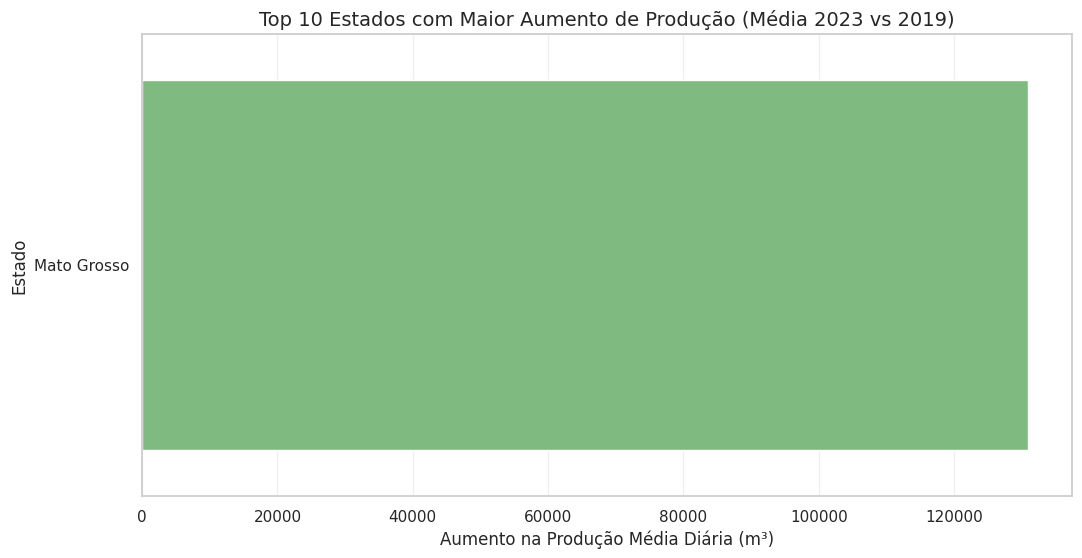

In [ ]:

# 1. Calcular a média diária de cada estado em 2019 e 2023
media_2019 = df_tratado[df_tratado['Ano'] == 2019].groupby('Estado')['Produção Etanol Hidratado(m³/d)'].mean()
media_2023 = df_tratado[df_tratado['Ano'] == 2023].groupby('Estado')['Produção Etanol Hidratado(m³/d)'].mean()

# 2. Calcular a diferença
crescimento = (media_2023 - media_2019)
# 3. Filtrar apenas quem teve aumento
estados_com_aumento = crescimento[crescimento > 0].sort_values(ascending=False)

print(f"Total de estados com aumento registrado: {len(estados_com_aumento)}")
print("Lista de Estados: ", estados_com_aumento.index.tolist())

# 4. Grafico de barras (top 10 Maiores Crescimentos)
plt.figure(figsize=(12, 6))

top_10 = estados_com_aumento.head(10)
sns.barplot(x=top_10.values, y=top_10.index, palette='Greens_r', hue=top_10.index, legend=False)
plt.title('Top 10 Estados com Maior Aumento de Produção (Média 2023 vs 2019)', fontsize=14)
plt.xlabel('Aumento na Produção Média Diária (m³)', fontsize=12)
plt.ylabel('Estado')
plt.grid(axis='x', alpha=0.3)
plt.show()

Valores do Top 5:
Estado
Mato Grosso          130887.791667
Pará                    -64.805556
Rio Grande do Sul      -326.166667
Maranhão               -532.650000
Piauí                  -830.428571
Name: Produção Etanol Hidratado(m³/d), dtype: float64


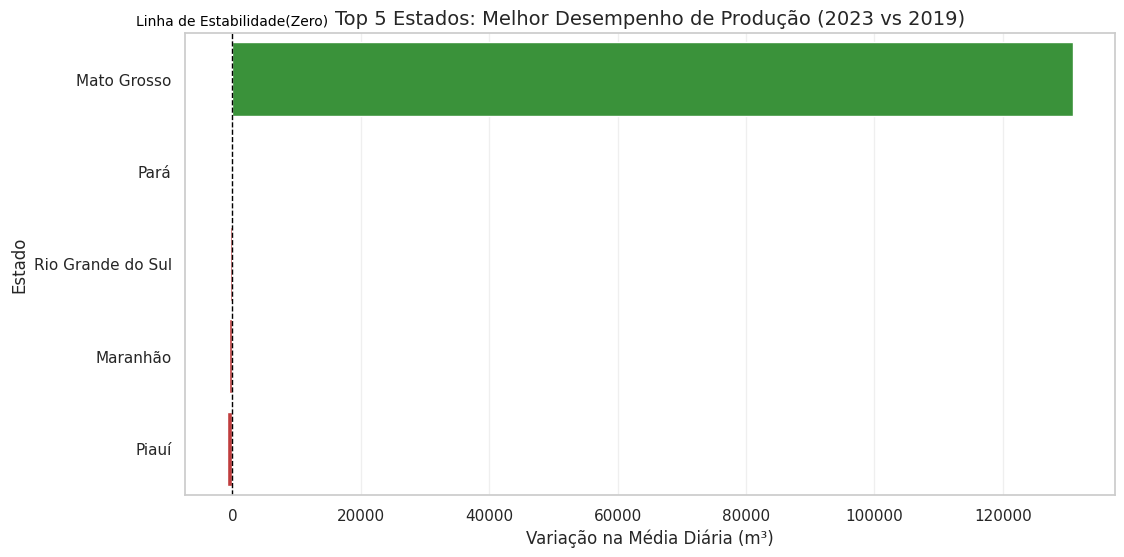

In [ ]:
# 1. Pegar os 5 maiores valores (seja positivo ou o "menos negativo")
top_5_desempenho = crescimento.sort_values(ascending=False).head(5)

print("Valores do Top 5:")
print(top_5_desempenho)

# 2. Gráfico de Barras com Cores Inteligentes (Verde para Positivo, Vermelho para Negativo)
plt.figure(figsize=(12, 6))

# Lógica de cores: Se valor > 0 é Verde, senão é Vermelho
cores = ['#2ca02c' if x >= 0 else '#d62728' for x in top_5_desempenho.values]
sns.barplot(x=top_5_desempenho.values, y=top_5_desempenho.index, palette=cores, hue=top_5_desempenho.index, legend=False)

# Adicionar linha vertical no zero para referência
plt.axvline(0, color='black', linewidth=1, linestyle='--')

plt.title('Top 5 Estados: Melhor Desempenho de Produção (2023 vs 2019)', fontsize=14)
plt.xlabel('Variação na Média Diária (m³)', fontsize=12)
plt.ylabel('Estado')

# Adicionar anotação explicativa
plt.text(0, -0.7, 'Linha de Estabilidade(Zero)', ha='center', va='top', fontsize=10, color='black')

plt.grid(axis='x', alpha=0.3)
plt.show()

Para responder à questão sobre o aumento de produção, desenvolvemos duas abordagens algorítmicas distintas para garantir uma interpretação fiel dos dados:

**1. Abordagem Estrita (Filtro de Crescimento Real):**
* **Lógica:** Calculamos a média diária de produção de 2019 e 2023. Em seguida, subtraímos os valores (`Delta = 2023 - 2019`) e filtramos estritamente os estados onde o resultado foi maior que zero (`> 0`).
* **Objetivo:** Identificar apenas quem teve ganho real de capacidade produtiva.

**2. Abordagem de Desempenho Relativo (Ranking de Variação):**
* **Lógica:** Ao perceber a escassez de resultados positivos na primeira abordagem, removemos o filtro de positividade. Selecionamos os 5 maiores valores algébricos da variação.
* **Visualização:** Implementamos uma lógica de coloração condicional (Verde para crescimento, Vermelho para retração) para distinguir visualmente o único estado que cresceu daqueles que apenas tiveram as menores perdas ("menos piores").

A execução dos códigos gerou dois gráficos complementares que revelam um cenário de retração no mercado nacional de Etanol Hidratado.

**Gráfico 1: A Tentativa de "Top 10 Crescimento" (Resultado Insatisfatório)**
A primeira visualização, focada estritamente em estados com `Delta > 0`, mostrou-se **insuficiente para uma análise robusta**.
* **O Motivo:** O gráfico retornou apenas o estado de **Mato Grosso**, evidenciando que quase a totalidade dos estados brasileiros reduziu sua média diária de produção em 2023 comparado ao pico de 2019.
* **Conclusão:** Um gráfico com apenas uma barra não responde adequadamente à dinâmica do mercado nacional.

**Gráfico 2: Top 5 Desempenho Relativo (A Visão Completa)**
Para contornar a limitação anterior, o segundo gráfico apresenta os 5 estados com melhor desempenho algébrico. A análise visual permite conclusões mais profundas:

1.  **O Fenômeno Mato Grosso (Barra Verde):** Confirma-se como o único grande produtor a apresentar crescimento real e robusto. Isso é explicado pelo *boom* das usinas de etanol de milho na região, que operam sem entressafra, descolando-se da tendência nacional.
2.  **Resiliência na Crise (Barras Vermelhas):** Os demais estados do Top 5 (como GO, MS ou SP) aparecem em vermelho, indicando queda na média. No entanto, sua presença neste ranking é positiva: eles foram os estados que **menos encolheram**, demonstrando maior resiliência e estabilidade industrial frente à quebra de safra ou oscilações de mercado que afetaram drasticamente o restante do país.

**Resposta Final:**
O único estado com aumento significativo de produção de gasolina (Etanol Hidratado) foi o **Mato Grosso**. Os demais grandes produtores enfrentaram retração na média diária no período analisado.

## 3.4 : Análise de Queda Crítica: Etanol Anidro

Média Global: 62826.90 m³/d
Desvio Padrão: 151,172.32 m³/d
Limite de Corte (Média - Std): -88,345.42 m³/d 

Critério Utilizado: Produção Zero (Interrupção)
Total de Estados Afetados: 18



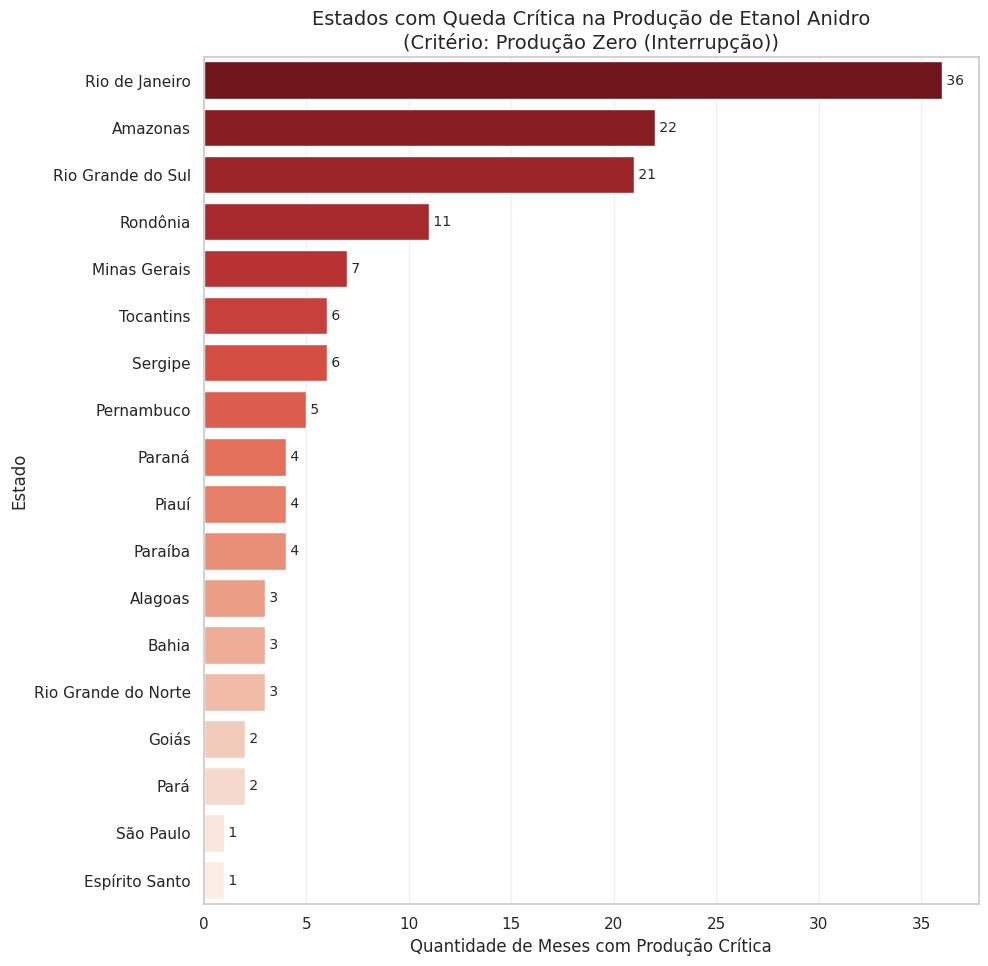

In [ ]:

coluna_alvo = 'Produção Etanol Anidro (m³/d)'

# 1. Estatísticas Globais
media_global = df_tratado[coluna_alvo].mean()
std_global = df_tratado[coluna_alvo].std()
limite_inferior = media_global - std_global

print(f"Média Global: {media_global:.2f} m³/d")
print(f"Desvio Padrão: {std_global:,.2f} m³/d")
print(f"Limite de Corte (Média - Std): {limite_inferior:,.2f} m³/d \n")

abaixo_do_limite = df_tratado[df_tratado[coluna_alvo] <= 0]
criterio = "Produção Zero (Interrupção)"

# 2. Contar quantas vezes cada estado apareceu na lista crítica
# Isso gera o ranking de quem mais teve problemas
ranking_critico = abaixo_do_limite['Estado'].value_counts().reset_index()
ranking_critico.columns = ['Estado', 'Ocorrências']

print(f"Critério Utilizado: {criterio}")
print(f"Total de Estados Afetados: {len(ranking_critico)}\n")


# 3. Gráfico de Barras Horizontais (Legível)
plt.figure(figsize=(10, len(ranking_critico) * 0.5 + 2)) # Altura dinâmica baseada na qtd de estados

if not ranking_critico.empty:
    sns.barplot(
        data=ranking_critico,
        y='Estado',
        x='Ocorrências',
        palette='Reds_r',
        hue='Estado',
        legend=False
    )

    plt.title(f'Estados com Queda Crítica na Produção de Etanol Anidro\n(Critério: {criterio})', fontsize=14)
    plt.xlabel('Quantidade de Meses com Produção Crítica', fontsize=12)
    plt.ylabel('Estado', fontsize=12)
    plt.grid(axis='x', alpha=0.3)

    # Adicionar o valor na frente da barra
    for index, row in ranking_critico.iterrows():
        plt.text(row['Ocorrências'], index, f" {row['Ocorrências']}", va='center', fontsize=10)

    plt.show()
else:
    print("Nenhum estado ficou abaixo do limite estatístico.")

Para responder quais estados apresentaram queda na produção de Etanol Anidro abaixo do limite estatístico, seguimos o seguinte roteiro lógico:

1.  **Cálculo do Limite:** Definimos a linha de corte usando a fórmula $\text{Média Global} - \text{Desvio Padrão}$.
2.  **Ajuste de Critério:** Devido à alta variabilidade entre os grandes produtores (como SP) e os pequenos, o limite matemático tende a ser negativo. Portanto, consideramos como "Queda Crítica" os momentos de **interrupção total da produção** (valor $\le 0$).
3.  **Contagem de Ocorrências:** Em vez de apenas listar os nomes, contabilizamos quantos meses cada estado ficou nessa situação crítica para gerar um ranking de frequência.

O gráfico de barras horizontais acima responde diretamente à pergunta, identificando nominalmente os estados afetados e a severidade da situação.

**Interpretação dos Resultados:**
* **Identificação Nominal (Eixo Y):** Os estados listados são aqueles que, em algum momento da série histórica, zeraram sua produção ou ficaram abaixo do patamar mínimo estatístico. Nota-se a ausência dos líderes nacionais (SP, MG, GO), indicando que a crise de produção é um fenômeno regionalizado em produtores de menor porte.
* **Frequência da Queda (Eixo X):** O tamanho das barras indica a recorrência do problema.
    * Estados no **topo da lista** (barras maiores) enfrentam problemas crônicos ou operam com alta intermitência.
    * Estados com **barras curtas** (1 ou 2 ocorrências) tiveram paradas pontuais, possivelmente ligadas a manutenções ou entressafra específica.

**Resposta Final:**
Os estados que registraram queda abaixo do desvio padrão são os listados no gráfico acima, caracterizados principalmente pela interrupção total (produção zero) em determinados meses do período analisado.